# $$\text{Single layer A.N.N. exercise}$$

The data is stored in 'dataExercise1.txt', which contains 1000 points. The first three columns represent the input variables, whilst the three last columns represent the output variables.

The Artificial Neural Network (A.N.N.) we want to build

1. Three input and output variables.
2. The activiation function should be defined as rectified linear units (relu).
3. The output layer should be defined by linear activation function (linear).
4. Set the number of neurons and epochs to 50.

#### $$\text{1 - Importing the necessary python modules}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

import torch
import torch.optim as optim
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

#### $$\text{GPU Acceleration with CUDA}$$

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### $$\text{2 - Splitting the data}$$

In [3]:
data = np.loadtxt('dataExercise1.txt')

In [4]:
inputData, outputData = data[:, 0:3], data[:, 3:6]

In [5]:
X = torch.tensor(inputData, dtype=torch.float32)
y = torch.tensor(outputData, dtype=torch.float32)

#### $$\text{3 - Creating the single layer A.N.N.}$$

In [6]:
class SingleLayerANN(nn.Module):
    def __init__(self, numHidden=50):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(3, numHidden),           # 3 inputs, 50 hidden neurons
            nn.ReLU(),                         # ReLU activation
            nn.Linear(numHidden, 3)            # 3 outputs, linear activation
        )

    def forward(self, x):
        return self.model(x)

The default ``` batch_size ```, if not defined, is the entire dataset tensor passed through the model. Therefore, we use DataLoader to define a matching batch size to TensorFlow (which is by default 32).

In [7]:
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [8]:
model = SingleLayerANN().to(device)

In [9]:
lossFunction = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#### $$\text{4 - Training run}$$

In [10]:
epochs = 50

Before training the model, we call ```model.train()``` to enter into training mode. Apparently some of the layers behaves differently during training and evaluation. 

PyTorch computes the gradient of the loss with respect to each trainable model parameter. ```loss.backward()``` performs backpropagation.

In [11]:
for epoch in range(epochs):
    model.train()

    epoch_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        prediction = model(X_batch)

        loss = lossFunction(prediction, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    average_epoch_loss = epoch_loss / len(loader)

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {average_epoch_loss:.6f}")

Epoch 1/50, Loss: 0.088527
Epoch 2/50, Loss: 0.023159
Epoch 3/50, Loss: 0.017366
Epoch 4/50, Loss: 0.012344
Epoch 5/50, Loss: 0.009055
Epoch 6/50, Loss: 0.007623
Epoch 7/50, Loss: 0.006925
Epoch 8/50, Loss: 0.006428
Epoch 9/50, Loss: 0.006083
Epoch 10/50, Loss: 0.005952
Epoch 11/50, Loss: 0.005571
Epoch 12/50, Loss: 0.005422
Epoch 13/50, Loss: 0.004813
Epoch 14/50, Loss: 0.004236
Epoch 15/50, Loss: 0.003824
Epoch 16/50, Loss: 0.003477
Epoch 17/50, Loss: 0.003063
Epoch 18/50, Loss: 0.002720
Epoch 19/50, Loss: 0.002509
Epoch 20/50, Loss: 0.002279
Epoch 21/50, Loss: 0.002106
Epoch 22/50, Loss: 0.001880
Epoch 23/50, Loss: 0.001741
Epoch 24/50, Loss: 0.001611
Epoch 25/50, Loss: 0.001516
Epoch 26/50, Loss: 0.001420
Epoch 27/50, Loss: 0.001320
Epoch 28/50, Loss: 0.001251
Epoch 29/50, Loss: 0.001173
Epoch 30/50, Loss: 0.001093
Epoch 31/50, Loss: 0.001068
Epoch 32/50, Loss: 0.000997
Epoch 33/50, Loss: 0.000928
Epoch 34/50, Loss: 0.000899
Epoch 35/50, Loss: 0.000892
Epoch 36/50, Loss: 0.000845
E

#### $$\text{5 - Visualizing the accuracy}$$

The operation ``` detach().cpu().numpy() ``` is applied from the left to right. 

1. ```detach()``` removes the tensors from PyTorch computation graph. Calling it creates a new tensor with the same numerical values, but without gradient tracking.

2. ```cpu()``` moves the GPU memory to CPU memory. 

3. ```numpy()``` converts the CPU tensor to a numpy array.

In [12]:
model.eval()

with torch.no_grad():
    X_device = X.to(device)
    prediction = model(X_device)

# Convert only when needed for plotting
prediction_np = prediction.detach().cpu().numpy()
y_np = y.detach().cpu().numpy()

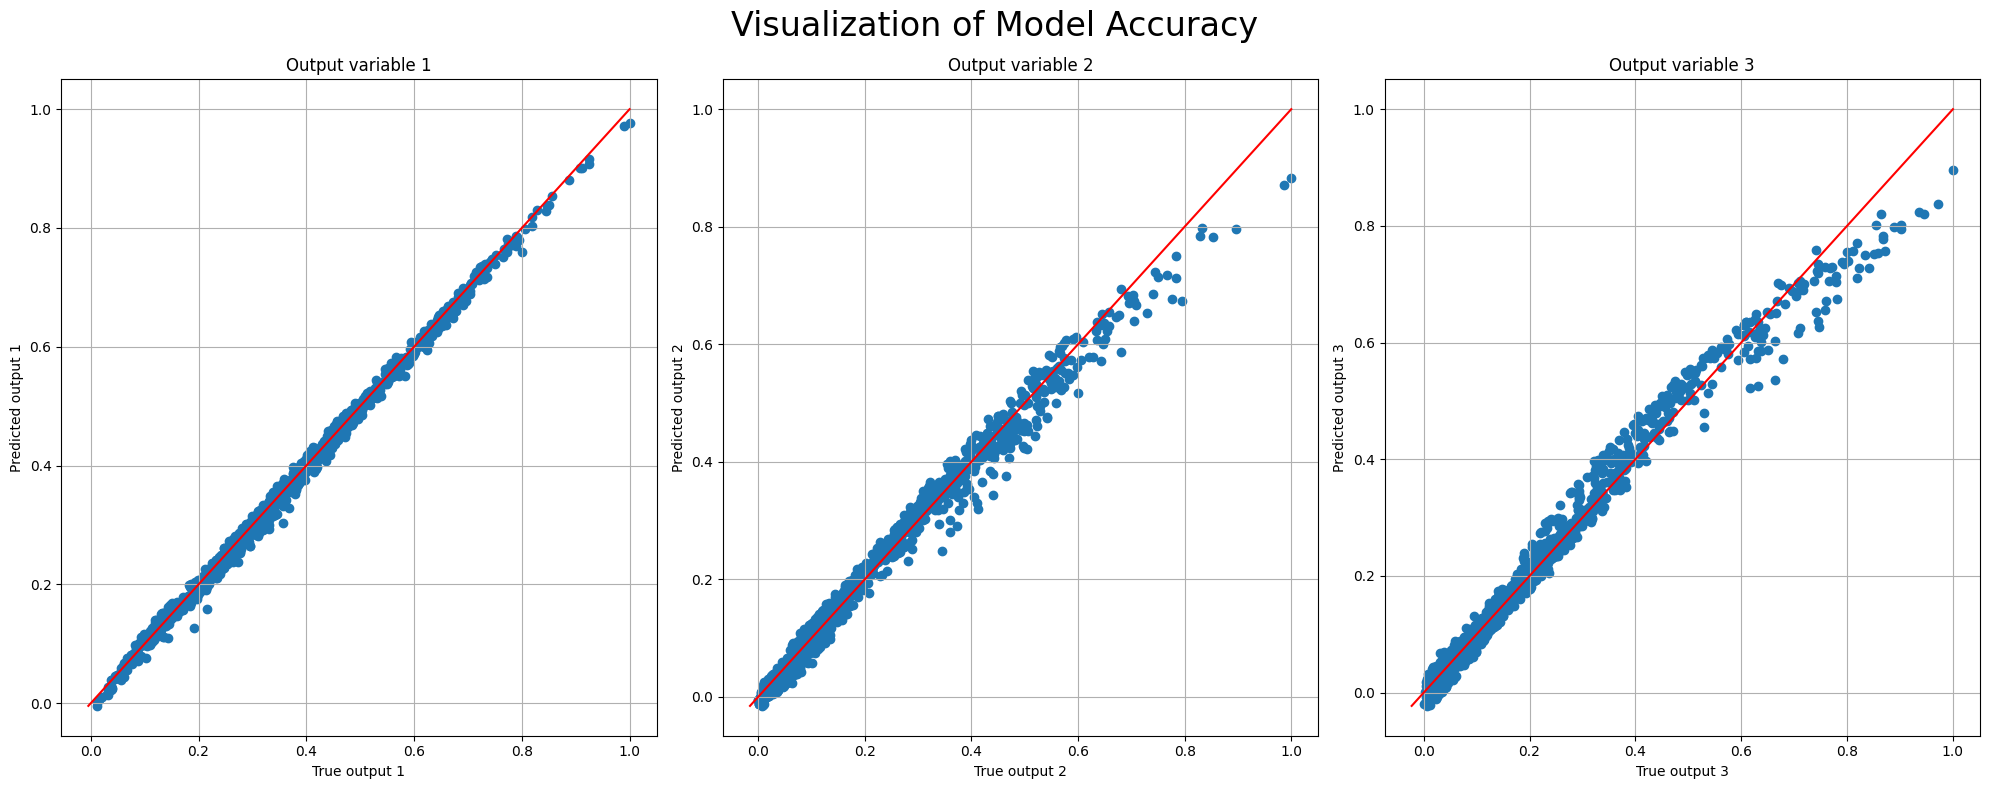

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle("Visualization of Model Accuracy", fontsize=24)

for i in range(3):
    ax[i].scatter(y_np[:, i], prediction_np[:, i])

    min_val = min(y_np[:, i].min(), prediction_np[:, i].min())
    max_val = max(y_np[:, i].max(), prediction_np[:, i].max())

    ax[i].plot([min_val, max_val], [min_val, max_val], color="r")

    ax[i].set_xlabel(f"True output {i + 1}")
    ax[i].set_ylabel(f"Predicted output {i + 1}")
    ax[i].set_title(f"Output variable {i + 1}")
    ax[i].grid()

fig.tight_layout()
plt.show()